<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/sparse_categorical_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (87554, 188)


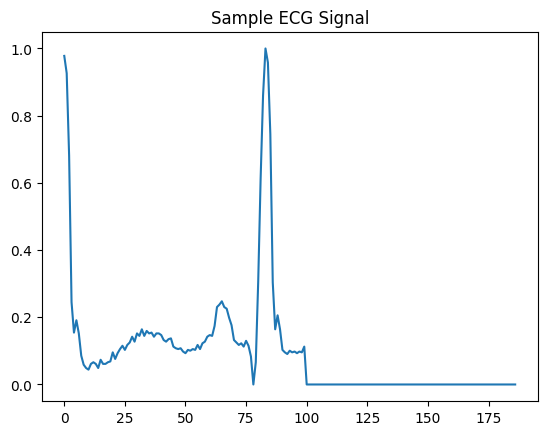

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

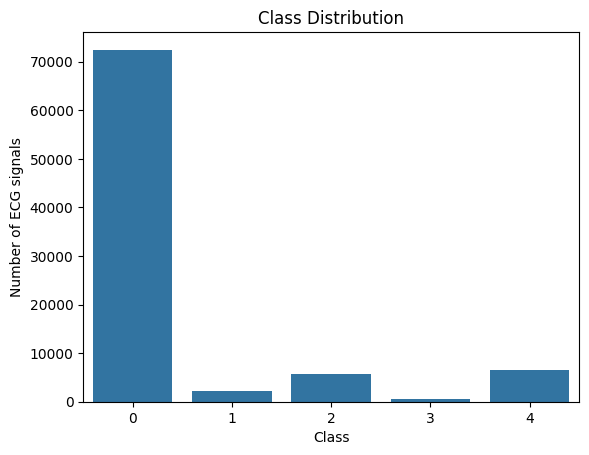

In [6]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [7]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [8]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [9]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [10]:
y_res_sparse = y_res
y_test_sparse = y_test

In [11]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [12]:
def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [13]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_sparse, test_size=0.2, random_state=42
)

In [15]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_sparse.iloc[train_idx], y_res_sparse.iloc[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 184s 48ms/step - accuracy: 0.9409 - loss: 0.1698
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 200s 47ms/step - accuracy: 0.9758 - loss: 0.0697
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 201s 47ms/step - accuracy: 0.9834 - loss: 0.0490
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 179s 47ms/step - accuracy: 0.9867 - loss: 0.0382
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 181s 48ms/step - accuracy: 0.9893 - loss: 0.0312

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 185s 48ms/step - accuracy: 0.9416 - loss: 0.1695
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 183s 48ms/step - accuracy: 0.9766 - loss: 0.0693
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 199s 48ms/step - accuracy: 0.9840 - loss: 0.0480
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 203s 48ms/step - accuracy: 0.9874 - loss: 0.0372
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 200s 47ms/step - accuracy: 0.9896 - loss: 0.0304

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 183s 48ms/step - accuracy: 0.9417 -

In [17]:
model = mobilenet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 234s 51ms/step - accuracy: 0.9497 - loss: 0.1463 - val_accuracy: 0.9621 - val_loss: 0.1102
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 267s 52ms/step - accuracy: 0.9803 - loss: 0.0586 - val_accuracy: 0.9599 - val_loss: 0.1142
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 235s 52ms/step - accuracy: 0.9861 - loss: 0.0411 - val_accuracy: 0.9597 - val_loss: 0.1123
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 228s 50ms/step - accuracy: 0.9891 - loss: 0.0322 - val_accuracy: 0.8209 - val_loss: 0.9479
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 229s 50ms/step - accuracy: 0.9911 - loss: 0.0270 - val_accuracy: 0.8571 - val_loss: 0.7533
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 229s 51ms/step - accuracy: 0.9923 - loss: 0.0227 - val_accuracy: 0.9606 - val_loss: 0.1230
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 262s 51ms/step - accuracy: 0.9934 - loss: 0.0196 - val_accuracy: 0.9926 - val_loss: 0.0227
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 245s 54ms/step - accuracy: 

In [20]:
# Predict validation data
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)

# Calculate MCC
val_mcc = matthews_corrcoef(y_val_final, y_val_pred)

print("Validation MCC:", val_mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step
Validation MCC: 0.850435491645508


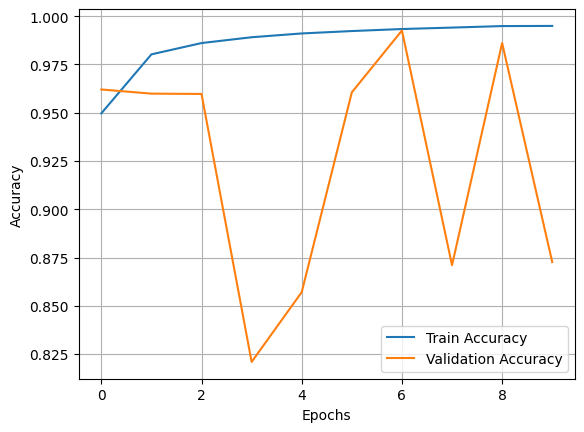

Final Training Accuracy: 0.9950
Final Validation Accuracy: 0.8727


In [21]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Final training & validation loss and accuracy

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]


print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

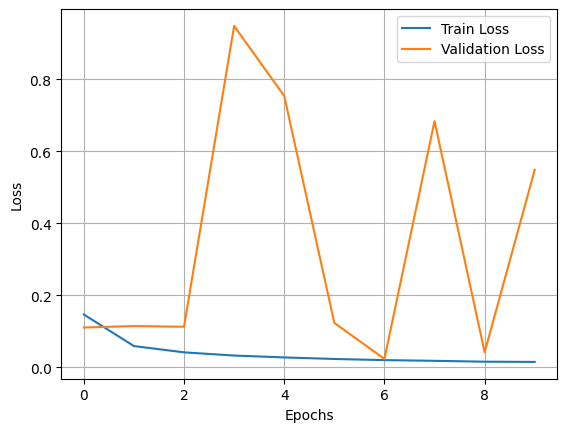

Final Training Loss: 0.0145
Final Validation Loss: 0.5482


In [23]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

In [24]:
test_loss, test_acc = model.evaluate(X_test, y_test_sparse, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

Test Loss: 0.15684038400650024
Test Accuracy: 0.9657925367355347
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98     72471
         1.0       0.88      0.66      0.75      2223
         2.0       0.98      0.78      0.87      5788
         3.0       0.97      0.35      0.51       641
         4.0       1.00      0.95      0.97      6431

    accuracy                           0.97     87554
   macro avg       0.96      0.75      0.82     87554
weighted avg       0.97      0.97      0.96     87554



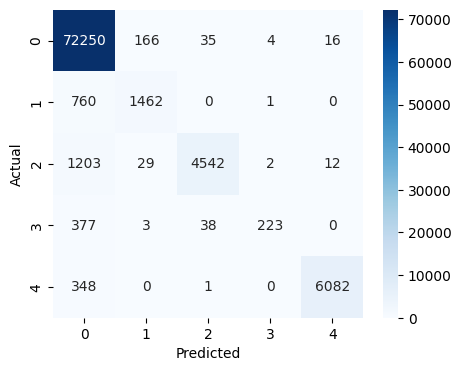

In [25]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()